# Docs Examples

In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

import diffinytrace as dit
from diffinytrace.basis_functions.bspline import basis_2d
import torch


In [7]:
cube = dit.integrators.Cube([[0, 1], [0, 1]])
points, weights = cube.sample([10, 10], method="midpoint")
volume = cube.get_volume()
all_in_bounds = cube.in_bounds(points)

print("Sampled points:\n", points)
print("Integration weights:\n", weights)
print("Cube volume:", volume)
print("All points in bounds:", all_in_bounds)

Sampled points:
 tensor([[0.0500, 0.0500],
        [0.0500, 0.1500],
        [0.0500, 0.2500],
        [0.0500, 0.3500],
        [0.0500, 0.4500],
        [0.0500, 0.5500],
        [0.0500, 0.6500],
        [0.0500, 0.7500],
        [0.0500, 0.8500],
        [0.0500, 0.9500],
        [0.1500, 0.0500],
        [0.1500, 0.1500],
        [0.1500, 0.2500],
        [0.1500, 0.3500],
        [0.1500, 0.4500],
        [0.1500, 0.5500],
        [0.1500, 0.6500],
        [0.1500, 0.7500],
        [0.1500, 0.8500],
        [0.1500, 0.9500],
        [0.2500, 0.0500],
        [0.2500, 0.1500],
        [0.2500, 0.2500],
        [0.2500, 0.3500],
        [0.2500, 0.4500],
        [0.2500, 0.5500],
        [0.2500, 0.6500],
        [0.2500, 0.7500],
        [0.2500, 0.8500],
        [0.2500, 0.9500],
        [0.3500, 0.0500],
        [0.3500, 0.1500],
        [0.3500, 0.2500],
        [0.3500, 0.3500],
        [0.3500, 0.4500],
        [0.3500, 0.5500],
        [0.3500, 0.6500],
        [0.3500, 0.75

In [13]:
disc = dit.integrators.Disc(1.0)
points, weights = disc.sample(2**4, method="sobol_pow2")
volume = disc.get_volume()
all_in_bounds = disc.in_bounds(points)
print("Sampled points:", points)
print("Integration weights:", weights)
print("Disc area:", volume)
print("All points in bounds:", all_in_bounds)


Sampled points: tensor([[ 0.6750,  0.3692],
        [ 0.5520, -0.3629],
        [-0.4272,  0.1181],
        [-0.8669, -0.1983],
        [-0.3564,  0.9025],
        [-0.0575, -0.1811],
        [ 0.2433,  0.5214],
        [ 0.3537, -0.7420],
        [-0.6825,  0.5270],
        [-0.4280, -0.3032],
        [ 0.3263,  0.0347],
        [ 0.9270, -0.1732],
        [ 0.0449,  0.9193],
        [ 0.0191, -0.3579],
        [-0.4870,  0.5015],
        [-0.4669, -0.5496]])
Integration weights: tensor([0.1963, 0.1963, 0.1963, 0.1963, 0.1963, 0.1963, 0.1963, 0.1963, 0.1963,
        0.1963, 0.1963, 0.1963, 0.1963, 0.1963, 0.1963, 0.1963])
Disc area: 3.141592653589793
All points in bounds: tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])


In [14]:
callback_fun = lambda:None
callback_fun()

In [15]:
import diffinytrace.config as config
config.set_tolerance(1e-8)
config.set_show_iteration_count(True)
config.restore_default_settings()

tensor(0.) tensor(1.)


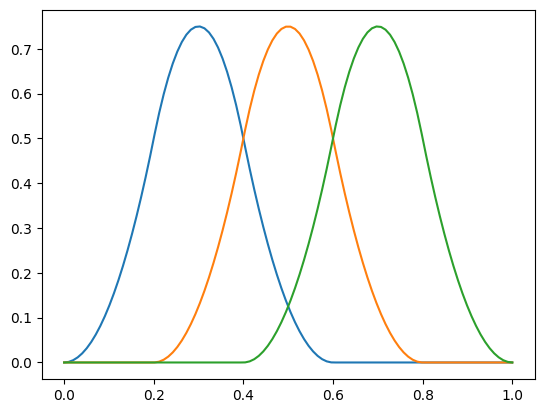

In [ ]:

import torch
import matplotlib.pyplot as plt
from diffinytrace.basis_functions import bspline
U = torch.tensor([0., 0.2, 0.4, 0.6, 0.8, 1])
n = 3
k = 3  # This is order 3
print(U[0], U[-1])
xis = torch.linspace(0, 1, 100)
xN = bspline.basis_1d(xis, U,k ,n,[0.,1.])
num_points = xN.shape[0]
tmp = xN.reshape(num_points, -1, 1) * xN.reshape(num_points, 1, -1)
for yin in xN.T:
    plt.plot(xis, yin)
plt.gca().set_aspect('equal')


True True
new_control_points tensor([[-0.9455, -1.7038],
        [-0.5192, -0.6632],
        [ 0.7904, -0.5718],
        [ 0.9161,  1.2840],
        [ 0.9054,  1.5760]])
control_points tensor([[-0.9455, -1.7038],
        [-0.4526, -0.5004],
        [ 0.9848, -0.5829],
        [ 0.9054,  1.5760]])
new_control_points tensor([[-0.9455, -1.7038],
        [-0.9267, -1.6578],
        [-0.3976, -0.5036],
        [ 0.9818, -0.5004],
        [ 0.9054,  1.5760]])
control_points tensor([[-0.9455, -1.7038],
        [-0.4526, -0.5004],
        [ 0.9848, -0.5829],
        [ 0.9054,  1.5760]])
new_control_points tensor([[-0.9455, -1.7038],
        [-0.5137, -0.6496],
        [ 0.8066, -0.5727],
        [ 0.9153,  1.3083],
        [ 0.9054,  1.5760]])
control_points tensor([[-0.9455, -1.7038],
        [-0.4526, -0.5004],
        [ 0.9848, -0.5829],
        [ 0.9054,  1.5760]])
new_control_points tensor([[-0.9455, -1.7038],
        [-0.7974, -1.3423],
        [-0.0208, -0.5252],
        [ 0.9610,  0.06

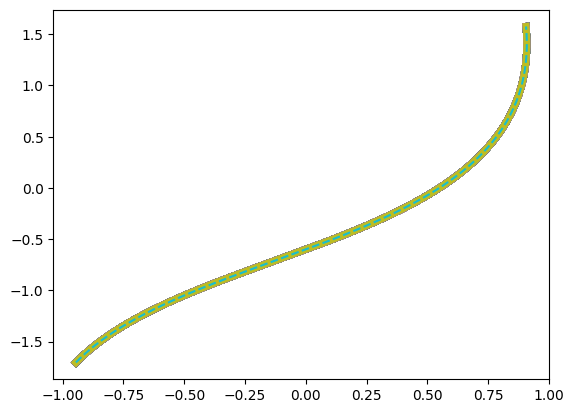

In [24]:
import torch
import numpy as np
import matplotlib.pyplot as plt
n = 4
control_points = torch.randn((n, 2))  # Random control points
k = 4  # Quadratic B-spline
U = torch.tensor([0.0] * (k - 1) + list(np.linspace(0, 1.0, n + k - 2 * (k - 1))) + [1.0] * (k - 1))
U = U.float()
print(U.shape[0] - k == n, n >= k)
for m in range(100):
    U_new, new_control_points = bspline.insert_knot1D_single(U, k, torch.rand((1)), control_points)
    print("new_control_points", new_control_points)
    print("control_points", control_points)
    xis = torch.linspace(0, 1, 1000)
    xN1 = bspline.basis_1d(xis,U, k, 3, [0,1.])
    out1 = xN1 @ control_points
    xN2 = bspline.basis_1d(xis,U_new, k, 4, [0,1.])
    out2 = xN2 @ new_control_points
    plt.plot(out1[:, 0], out1[:, 1], linewidth=5.0)
    plt.plot(out2[:, 0], out2[:, 1], "--")
    torch.mean((out1 - out2) ** 2)

In [26]:
import torch
from diffinytrace.basis_functions import bspline
n_x, n_y = 4, 4
control_points = torch.randn((n_x, n_y, 2))
k_x, k_y = 3, 3
U_x = torch.linspace(0, 1, n_x + k_x)
U_y = torch.linspace(0, 1, n_y + k_y)
points = torch.rand((100, 2))
surface = bspline.surface_2d(points, [U_x, U_y], [k_x, k_y], [n_x, n_y], (0.0, 1.0), (0.0, 1.0), control_points)
surface

tensor([[ 5.0737e-01,  6.8083e-01],
        [ 4.8796e-01, -2.5102e-01],
        [-2.6694e-01, -3.8622e-01],
        [ 2.5667e-03, -5.5414e-03],
        [-1.7805e-01, -3.8902e-01],
        [ 9.3093e-02,  1.2364e-01],
        [-1.6641e-02,  1.5389e-02],
        [-7.5921e-02, -2.3475e-01],
        [ 3.4169e-02, -2.6238e-02],
        [-1.1924e-01, -2.0544e-01],
        [-1.1543e-01, -1.4662e-01],
        [ 9.5893e-01, -1.5478e+00],
        [-9.1412e-02, -2.0961e-01],
        [ 6.1983e-02, -9.1166e-02],
        [ 1.5375e-01,  3.1623e-01],
        [ 1.8737e-01, -4.0098e-01],
        [ 1.2838e-01, -2.2399e-01],
        [ 6.2026e-01, -8.8184e-02],
        [ 1.0970e-02, -4.5772e-03],
        [-2.4879e-04, -1.7072e-04],
        [-6.6988e-02, -5.9969e-02],
        [-1.9763e-01, -9.2378e-02],
        [ 7.6130e-01, -1.4573e+00],
        [ 6.9597e-03, -1.4810e-02],
        [ 2.9485e-01, -4.6763e-01],
        [-1.5275e-01, -5.6191e-02],
        [-5.6799e-01, -4.3403e-01],
        [-6.3098e-02, -8.023